In [1]:
!pip install xgboost shap -q

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import r2_score


In [3]:
from google.colab import drive
drive.mount('/content/drive')

DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/'

Mounted at /content/drive


In [4]:
df_full = pd.read_pickle(f"{DESTINATION_DIR}df_full_with_embeddings.pkl")

In [5]:
emb_df = pd.read_pickle(f"{DESTINATION_DIR}combined_embeddings.pkl")

In [6]:


target_col = 'score' 

# Save the combined DataFrame for future use    
# Drop the target and any other non-predictive metadata columns present in df_encoded
cols_to_drop = [target_col, 'id', 'author', 'created_utc', 'created_at', 'post', 'safe_content', 'split', 'source']
X = df_full.drop(columns=[col for col in cols_to_drop if col in df_full.columns])
y = df_full[target_col]
y_raw = df_full[target_col].clip(lower=0)
y = np.log1p(y_raw) 

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# 4. Build the Random Forest Regression Model
model_rf = RandomForestRegressor(
    n_jobs=-1,         # Uses all available CPU cores for faster parallel training
    random_state=42
)

# 5. Train the model
# Random Forest does not use early stopping or an eval_set during the .fit() step
print("Training Random Forest...")
model_rf.fit(X_train, y_train)

# Optional: Check performance on the validation set
y_val_pred = model_rf.predict(X_val)
val_r2 = r2_score(y_val, y_val_pred)
print(f"R2 Score on Validation Set: {val_r2:.4f}")

# 6. Predict on the test set
y_pred = model_rf.predict(X_test)

# 7. Evaluate the model using R-squared (R2) score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score on Test Set: {r2:.4f}")




# ==========================================
# DIAGNOSTICS: LEARNING CURVE
# ==========================================



Train shape: (10676, 1546)
Validation shape: (2288, 1546)
Test shape: (2288, 1546)
Training Random Forest...
R2 Score on Validation Set: 0.4491
R2 Score on Test Set: 0.4129


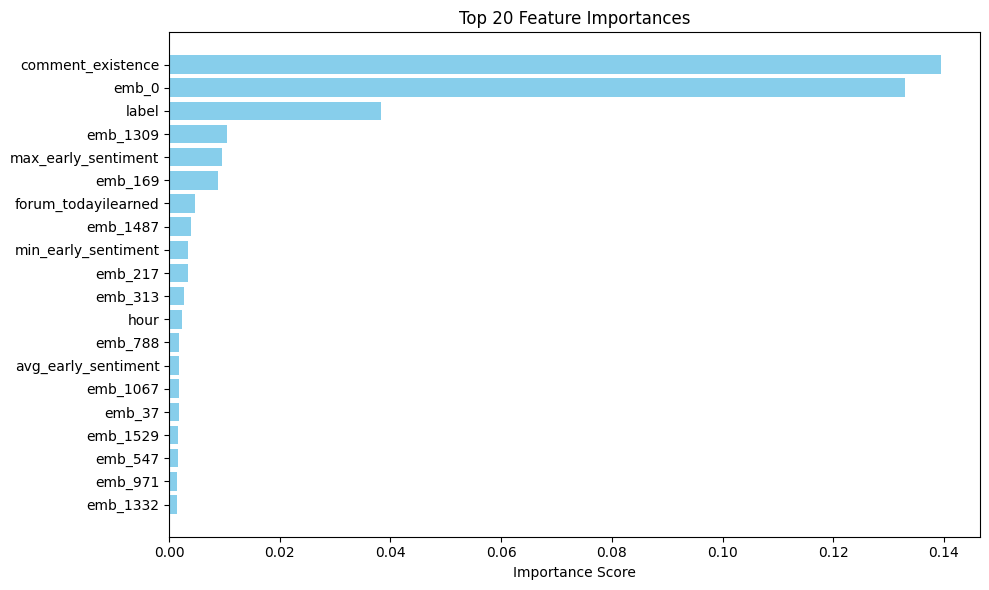

In [7]:
importances = model_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 features to avoid a massive, unreadable chart
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:top_n][::-1], feature_df['Importance'][:top_n][::-1], color='skyblue')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Generating Learning Curve (this may take a moment)...


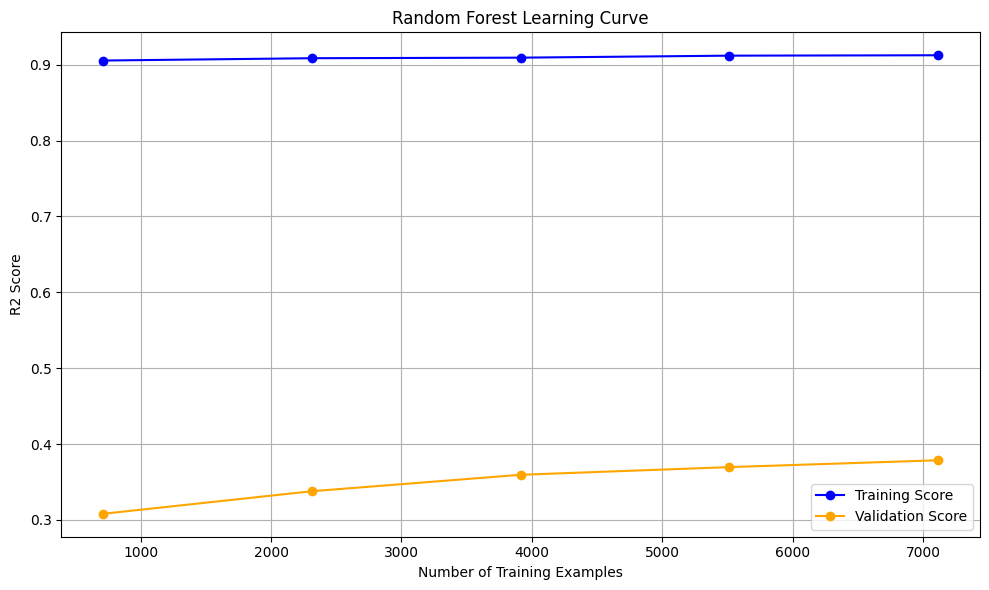

In [8]:
print("Generating Learning Curve (this may take a moment)...")
train_sizes = np.linspace(0.1, 1.0, 5) # Test at 10%, 32.5%, 55%, 77.5%, and 100% of data

train_sizes_abs, train_scores, val_scores = learning_curve(
    model_rf, X_train, y_train, 
    train_sizes=train_sizes, 
    cv=3, # 3-fold cross-validation
    scoring='r2', 
    n_jobs=-1
)

# Calculate means and standard deviations
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plot the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='orange', label='Validation Score')
plt.title('Random Forest Learning Curve')
plt.xlabel('Number of Training Examples')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
import umap

# 1. Prepare Base Features and Target
target_col = 'score' 
cols_to_drop = [target_col, 'id', 'author', 'created_utc', 'created_at', 'post', 'safe_content', 'split', 'source']
X_base = df_full[['comment_existence',
       'avg_early_sentiment', 'max_early_sentiment', 'min_early_sentiment',
    'forum_philosophy', 'forum_technology',
       'forum_todayilearned', 'hour',"label"]]
y = df_full[target_col]
y_raw = df_full[target_col].clip(lower=0)
y = np.log1p(y_raw) 

# 2. Prepare Embeddings DataFrame separately

# 3. Split the data 
# Splitting base features and embeddings simultaneously to keep rows aligned
X_base_train, X_base_temp, emb_train, emb_temp, y_train, y_temp = train_test_split(
    X_base, emb_df, y, test_size=0.30, random_state=42
)

X_base_val, X_base_test, emb_val, emb_test, y_val, y_test = train_test_split(
    X_base_temp, emb_temp, y_temp, test_size=0.50, random_state=42
)

# 4. Initialize and Apply UMAP to the Embeddings
n_components = 50 
print(f"Applying UMAP to reduce embeddings to {n_components} dimensions...")
print("(This may take a moment depending on the size of your dataset)")

# Initialize UMAP. random_state ensures reproducibility.
reducer = umap.UMAP(n_components=n_components, random_state=42)

# FIT ONLY ON TRAINING DATA to prevent data leakage, then transform all sets
emb_train_umap = reducer.fit_transform(emb_train)
emb_val_umap = reducer.transform(emb_val)
emb_test_umap = reducer.transform(emb_test)

# Convert back to DataFrames with proper indices so we can merge them
umap_cols = [f'umap_emb_{i}' for i in range(n_components)]
df_emb_train_umap = pd.DataFrame(emb_train_umap, index=X_base_train.index, columns=umap_cols)
df_emb_val_umap = pd.DataFrame(emb_val_umap, index=X_base_val.index, columns=umap_cols)
df_emb_test_umap = pd.DataFrame(emb_test_umap, index=X_base_test.index, columns=umap_cols)

# 5. Recombine the UMAP embeddings with the base features
X_train_final = pd.concat([X_base_train, df_emb_train_umap], axis=1)
X_val_final = pd.concat([X_base_val, df_emb_val_umap], axis=1)
X_test_final = pd.concat([X_base_test, df_emb_test_umap], axis=1)

print(f"Final Training Data Shape: {X_train_final.shape}")

# 6. Build and Train the Random Forest Regression Model
print("Training Random Forest...")
model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    max_features=0.8,
    max_samples=0.8,
    n_jobs=-1,
    random_state=42
)

model_rf.fit(X_train_final, y_train)

# 7. Evaluate the model
y_pred = model_rf.predict(X_test_final)
r2 = r2_score(y_test, y_pred)

print("--- Results ---")
print(f"R2 Score on Test Set: {r2:.4f}")

Applying UMAP to reduce embeddings to 50 dimensions...
(This may take a moment depending on the size of your dataset)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Final Training Data Shape: (10676, 59)
Training Random Forest...
--- Results ---
R2 Score on Test Set: 0.3794


In [1]:
importances = model_rf.feature_importances_
feature_names = X_train_final.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 features to avoid a massive, unreadable chart
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(feature_df['Feature'][:top_n][::-1], feature_df['Importance'][:top_n][::-1], color='skyblue')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

NameError: name 'model_rf' is not defined

In [ ]:
print("Generating Learning Curve (this may take a moment)...")
train_sizes = np.linspace(0.1, 1.0, 5) # Test at 10%, 32.5%, 55%, 77.5%, and 100% of data

train_sizes_abs, train_scores, val_scores = learning_curve(
    model_rf, X_train_final, y_train, 
    train_sizes=train_sizes, 
    cv=3, # 3-fold cross-validation
    scoring='r2', 
    n_jobs=-1
)

# Calculate means and standard deviations
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Plot the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='orange', label='Validation Score')
plt.title('Random Forest Learning Curve')
plt.xlabel('Number of Training Examples')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

Generating Learning Curve (this may take a moment)...
